# Raman Spectroscopy Analysis (Raw Intensity Workflow)

This notebook loads multiple Raman CSV datasets, visualizes raw spectra, applies ALS baseline correction and Savitzky-Golay smoothing, detects peaks, and computes an average spectrum on a common Raman shift axis.

Processing assumptions:
- Raw intensity only (no normalization)
- No dark subtraction
- Useful for weak Raman signals (for example biomolecules such as lipoteichoic acid)

In [8]:
from pathlib import Path
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.sparse.linalg import spsolve

# ---- User settings ----
# Folder containing Raman CSV files (change this as needed).
data_folder = Path('all_csv_combined')
file_pattern = '*.csv'

# ALS baseline correction parameters
ALS_LAMBDA = 1e5
ALS_P = 0.01
ALS_ITERATIONS = 10

# Display range
X_MIN = 400
X_MAX = 1500

# Plot style
plt.style.use('default')

In [9]:
def load_raman_csv(file_path: Path):
    """Load one Raman CSV: column 1 = shift, column 2 = raw intensity."""
    df = pd.read_csv(file_path, header=None)
    if df.shape[1] < 2:
        raise ValueError(f'{file_path.name} has fewer than 2 columns.')

    x = pd.to_numeric(df.iloc[:, 0], errors='coerce')
    y = pd.to_numeric(df.iloc[:, 1], errors='coerce')
    cleaned = pd.DataFrame({'x': x, 'y': y}).dropna()

    cleaned = cleaned.sort_values('x')
    cleaned = cleaned.groupby('x', as_index=False)['y'].mean()

    # Filter out Rayleigh peak and high-frequency noise before baseline correction
    cleaned = cleaned[(cleaned["x"] >= X_MIN) & (cleaned["x"] <= X_MAX)]
    return cleaned['x'].to_numpy(), cleaned['y'].to_numpy()


def load_spectra_from_folder(folder: Path, pattern: str = '*.csv'):
    """Load all matching CSV files from a folder."""
    files = sorted(glob.glob(str(folder / pattern)))
    if not files:
        raise FileNotFoundError(f'No files found in {folder} matching {pattern}')

    spectra = []
    for f in files:
        file_path = Path(f)
        x, y = load_raman_csv(file_path)
        if len(x) > 10:
            spectra.append({'name': file_path.stem, 'x': x, 'y_raw': y})
        else:
            print(f'Skipping {file_path.name} (too few points in range)')

    return spectra


def als_baseline(y, lam=1e5, p=0.01, niter=10):
    """Asymmetric Least Squares baseline correction."""
    y = np.asarray(y, dtype=float)
    length = y.size

    d = sparse.diags([1, -2, 1], [0, 1, 2], shape=(length - 2, length), format='csc')
    w = np.ones(length)

    for _ in range(niter):
        w_mat = sparse.spdiags(w, 0, length, length)
        z = spsolve(w_mat + lam * (d.T @ d), w * y)
        w = p * (y > z) + (1 - p) * (y <= z)

    return z


def baseline_correct_spectrum(y_raw):
    """Apply ALS baseline correction only (no smoothing)."""
    baseline = als_baseline(y_raw, lam=ALS_LAMBDA, p=ALS_P, niter=ALS_ITERATIONS)
    corrected = y_raw - baseline
    return baseline, corrected

In [10]:
spectra = load_spectra_from_folder(data_folder, file_pattern)
print(f'Loaded {len(spectra)} spectra from: {data_folder}')
for s in spectra:
    print(f"- {s['name']} ({len(s['x'])} points)")


Skipping 10sec,diffrenpower,10set__SP_11.csv (too few points in range)
Loaded 8 spectra from: all_csv_combined
- 10sec,diffrenpower,10set__sec-10_power-40_i-10 (676 points)
- 10sec,diffrenpower,10set__sec-10_power-50_i-10 (676 points)
- 10sec,diffrenpower,10set__sec-10_power-60_i-10 (676 points)
- 10sec,diffrenpower,10set__sec-10_power-70_i-10 (676 points)
- 45sec diffrent powrset2__sec-45_power-80_i-2 (676 points)
- 45sec diffrent powrset2__sec-45_power-80_i-2_2 (676 points)
- 45sec diffrent powrset2__sec-45_power-90_i-2 (676 points)
- 45sec diffrent powrset2__sec-45_power-95_i-2 (676 points)


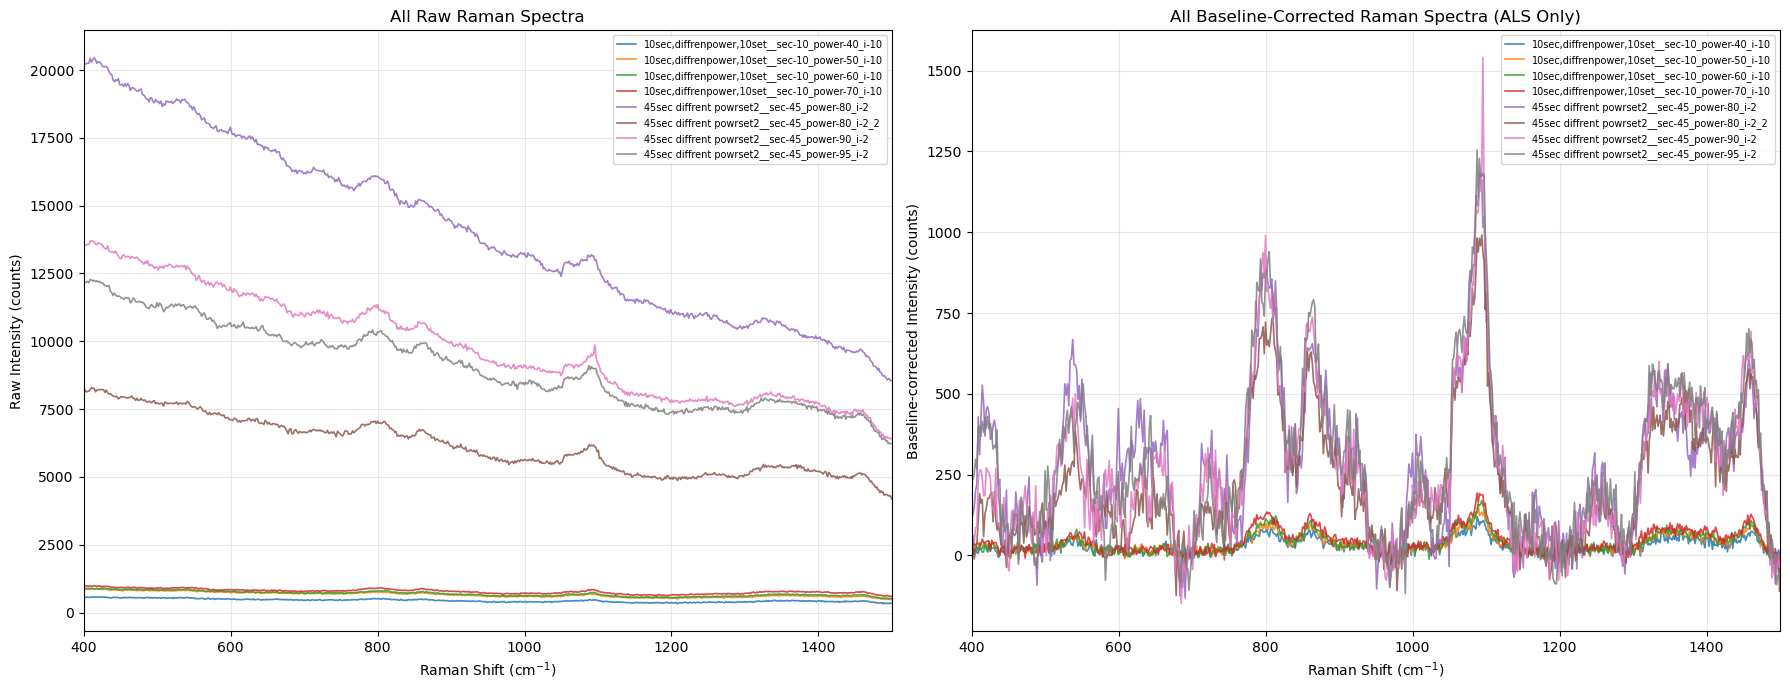

In [11]:
# Apply baseline correction only (no smoothing).
for s in spectra:
    baseline, corrected = baseline_correct_spectrum(s['y_raw'])
    s['baseline'] = baseline
    s['y_corrected'] = corrected

# One combined figure: left = all raw spectra, right = all baseline-corrected spectra.
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

for s in spectra:
    axes[0].plot(s['x'], s['y_raw'], linewidth=1.2, alpha=0.85, label=s['name'])
    axes[1].plot(s['x'], s['y_corrected'], linewidth=1.2, alpha=0.85, label=s['name'])

axes[0].set_title('All Raw Raman Spectra')
axes[0].set_xlabel('Raman Shift (cm$^{-1}$)')
axes[0].set_ylabel('Raw Intensity (counts)')
axes[0].set_xlim(X_MIN, X_MAX)
axes[0].grid(alpha=0.3)
axes[0].legend(loc='best', fontsize=7)

axes[1].set_title('All Baseline-Corrected Raman Spectra (ALS Only)')
axes[1].set_xlabel('Raman Shift (cm$^{-1}$)')
axes[1].set_ylabel('Baseline-corrected Intensity (counts)')
axes[1].set_xlim(X_MIN, X_MAX)
axes[1].grid(alpha=0.3)
axes[1].legend(loc='best', fontsize=7)

plt.tight_layout()
plt.show()

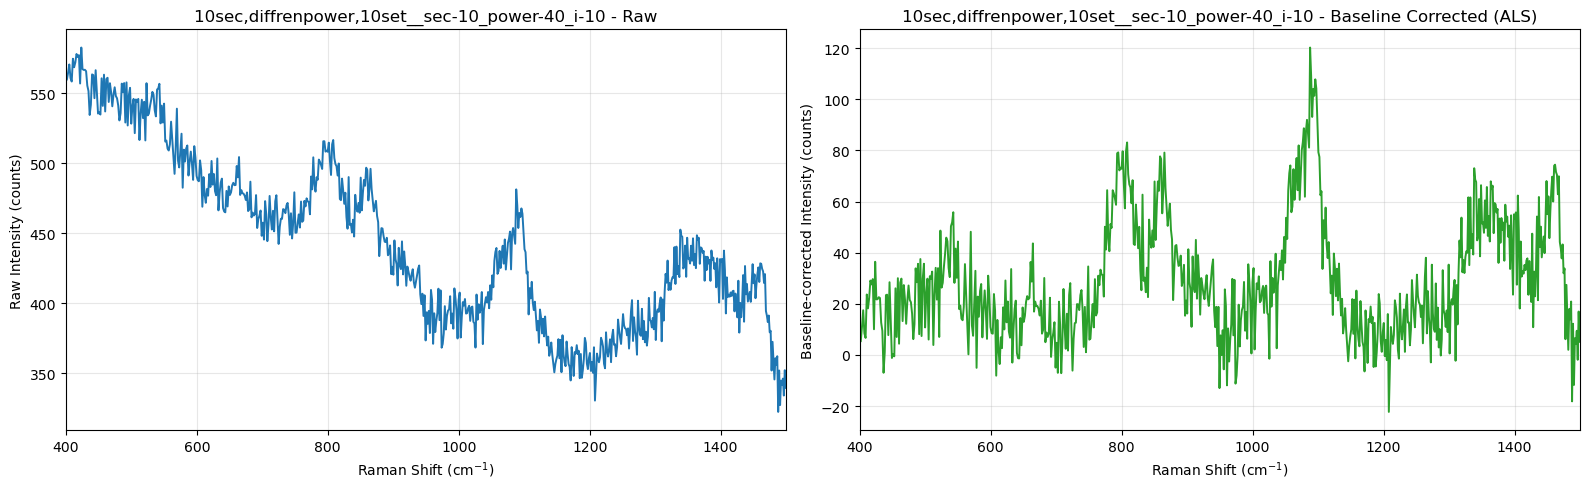

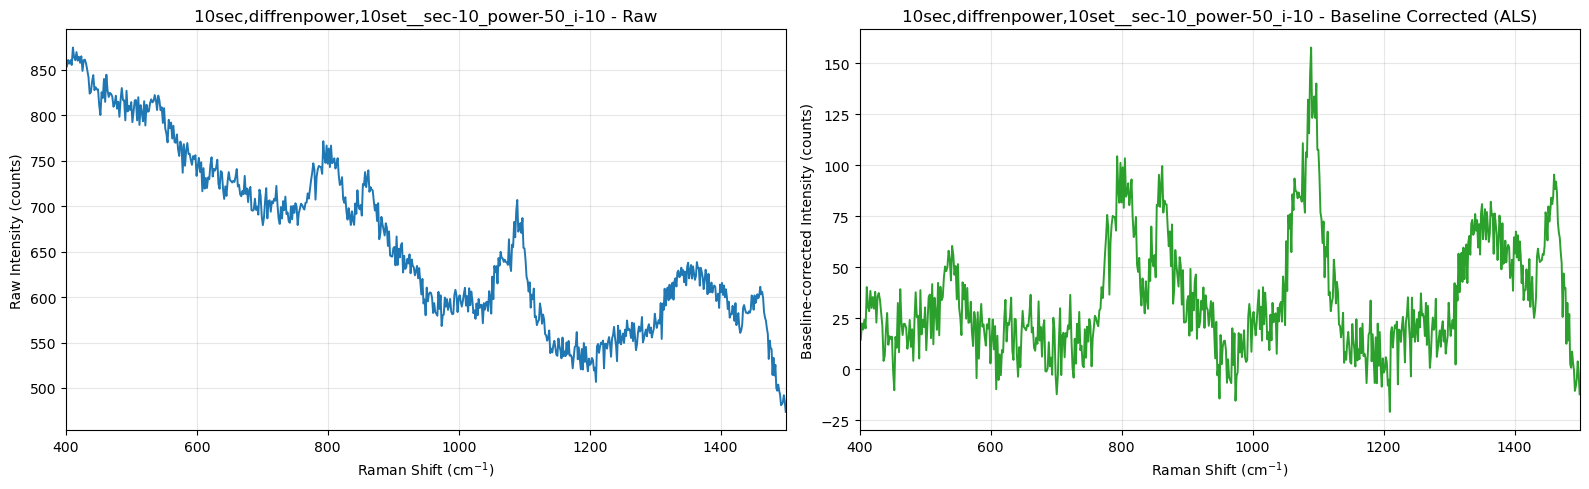

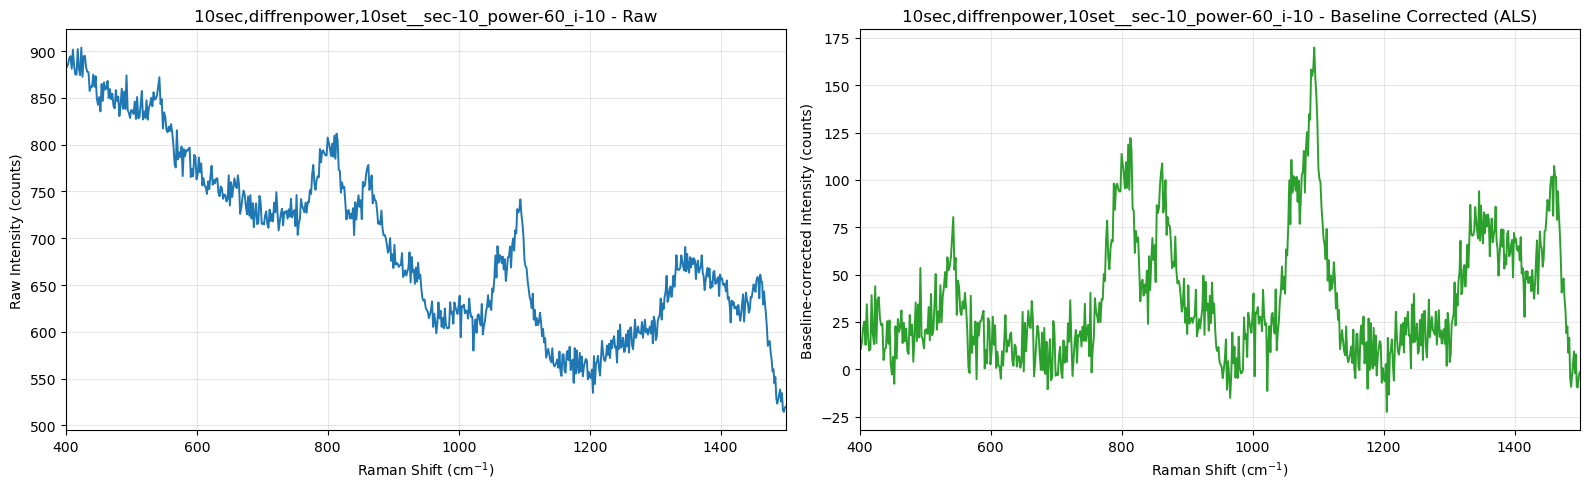

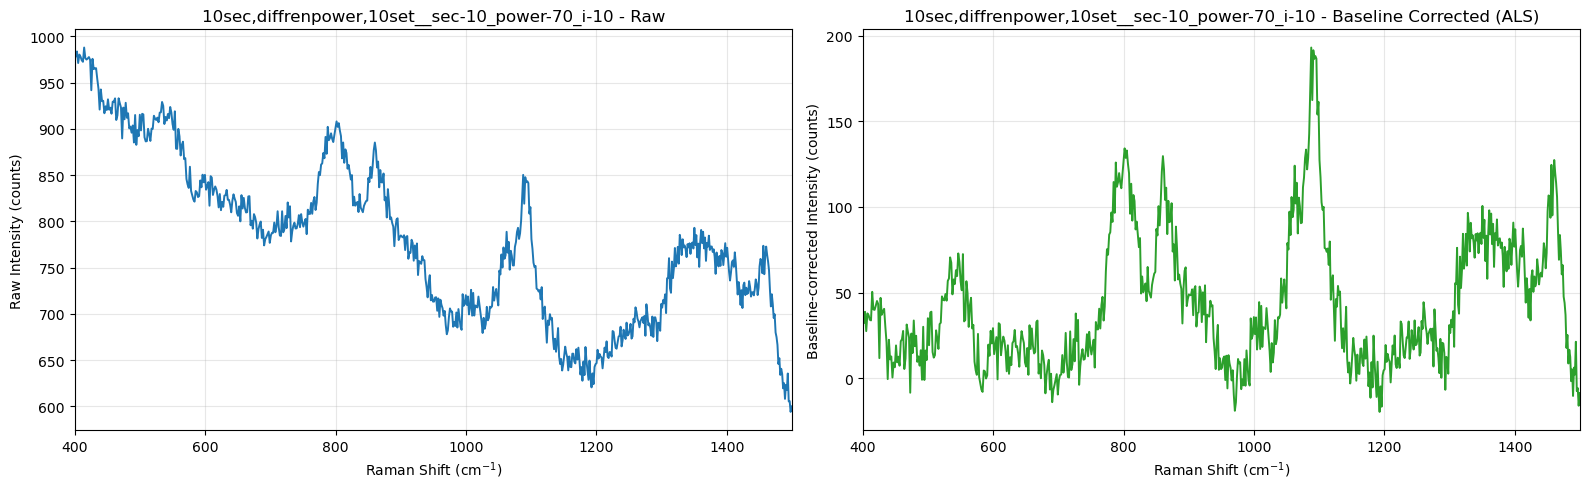

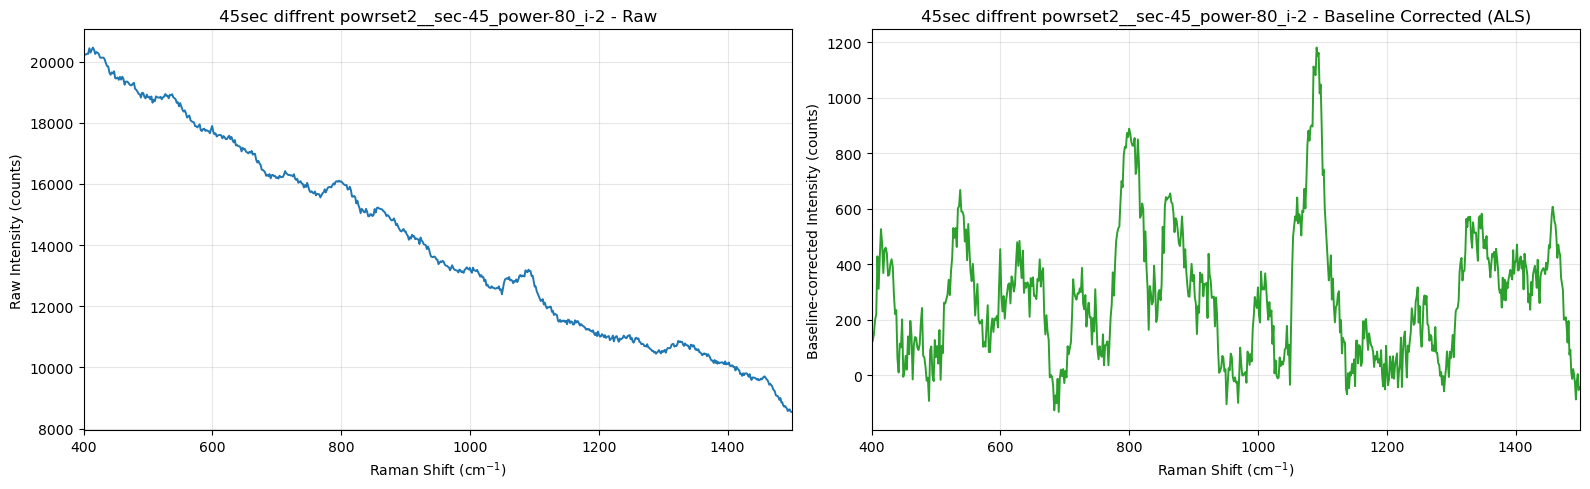

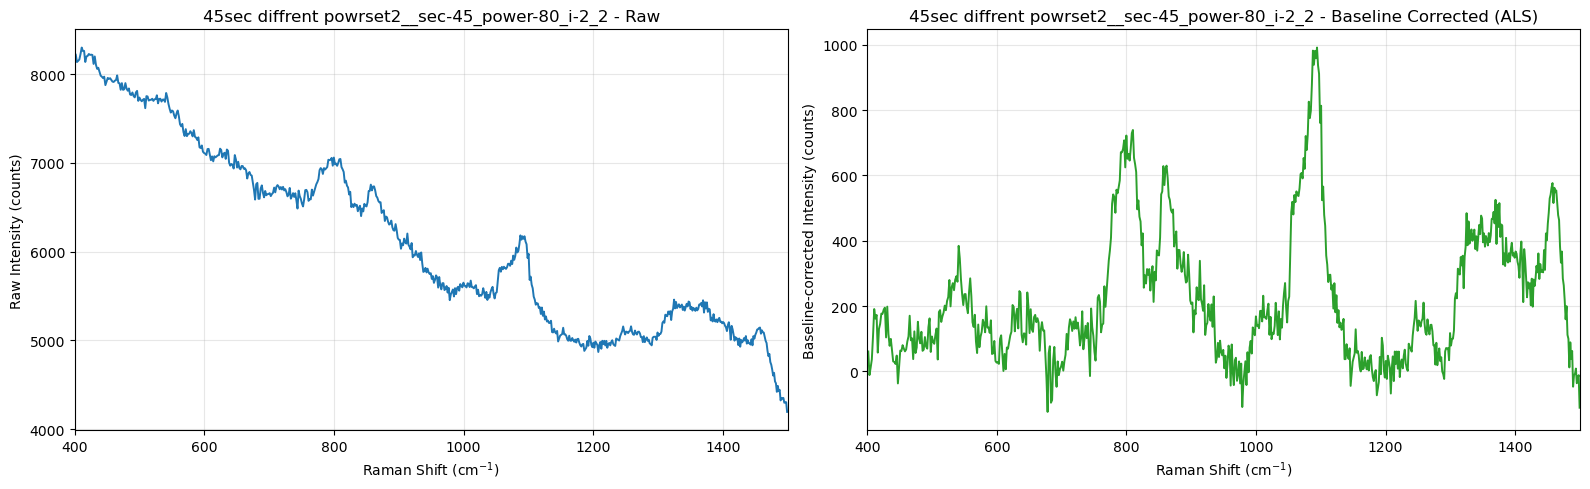

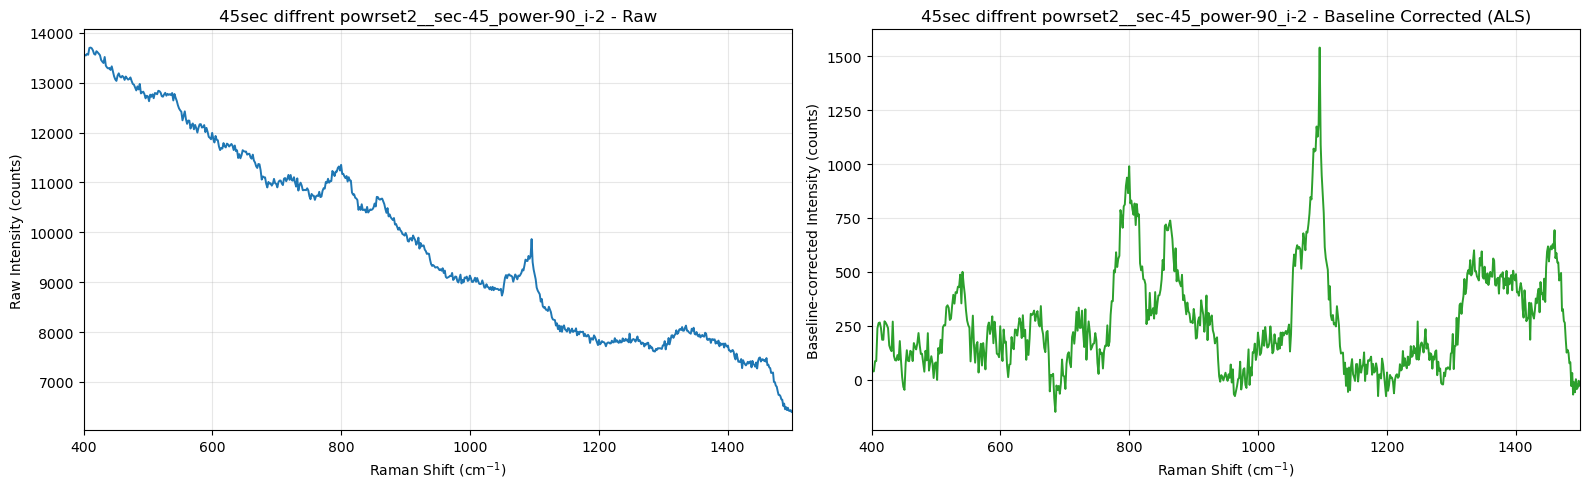

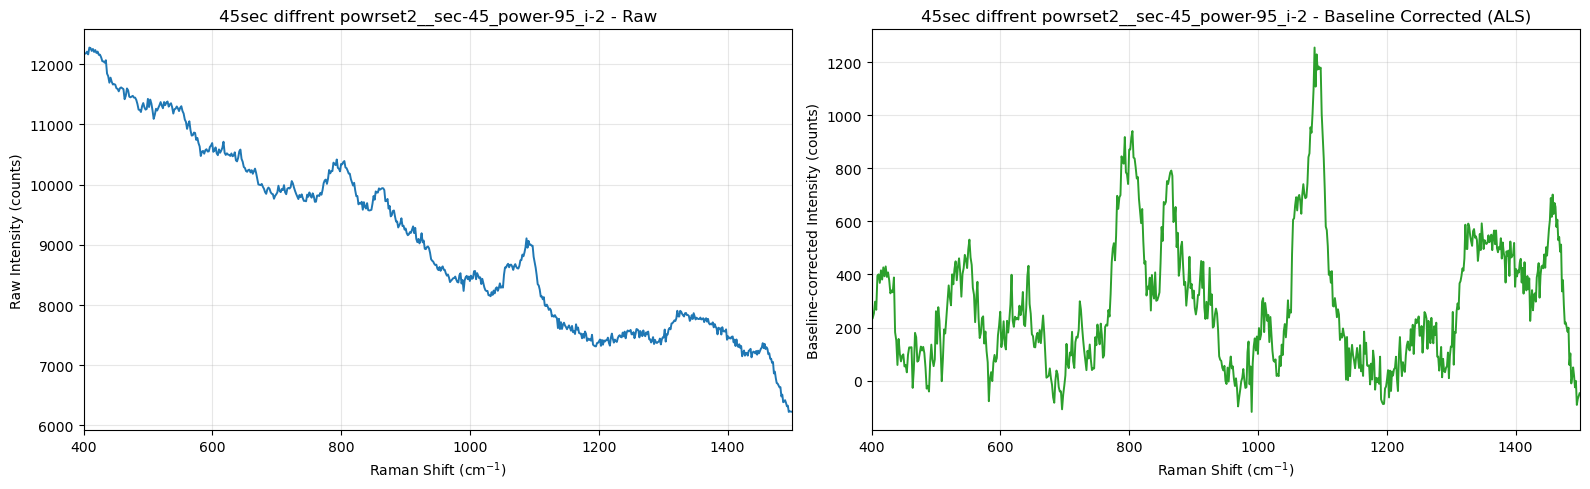

In [12]:
# Separate plots for each sheet: left raw, right baseline-corrected.
for s in spectra:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

    axes[0].plot(s['x'], s['y_raw'], color='tab:blue', linewidth=1.4)
    axes[0].set_title(f"{s['name']} - Raw")
    axes[0].set_xlabel('Raman Shift (cm$^{-1}$)')
    axes[0].set_ylabel('Raw Intensity (counts)')
    axes[0].set_xlim(X_MIN, X_MAX)
    axes[0].grid(alpha=0.3)

    axes[1].plot(s['x'], s['y_corrected'], color='tab:green', linewidth=1.4)
    axes[1].set_title(f"{s['name']} - Baseline Corrected (ALS)")
    axes[1].set_xlabel('Raman Shift (cm$^{-1}$)')
    axes[1].set_ylabel('Baseline-corrected Intensity (counts)')
    axes[1].set_xlim(X_MIN, X_MAX)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [13]:
print('Average spectrum cell removed per request.')

Average spectrum cell removed per request.


In [14]:
print('Smoothing and SNR cells removed per request.')

Smoothing and SNR cells removed per request.
